In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
from tensorflow.python.keras import utils
from keras.models import Sequential
from keras.layers import Dense, Flatten, InputLayer
import keras
import imageio
from PIL import Image

Age group: MIDDLE


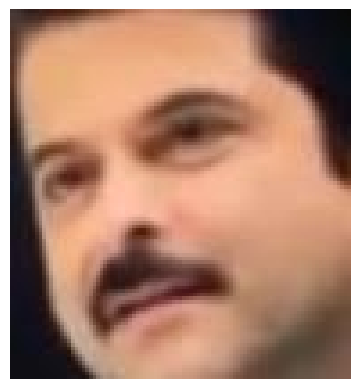

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
# Displaying any random movie character along with age group
np.random.seed(10)
idx = np.random.choice(train.index)
img_name = train.ID[idx]
img = imageio.v2.imread(os.path.join("Train/Train", img_name))
print('Age group:', train.Class[idx])
plt.imshow(img)
plt.axis('off')
plt.show()


In [3]:
temp = []
for img_name in train.ID:
    img_path = os.path.join('Train/Train', img_name)
    img = imageio.v2.imread(img_path)
    img = np.array(Image.fromarray(img).resize((32, 32))).astype('float32')    
    temp.append(img)

train_x = np.stack(temp)

In [4]:
temp = []
for img_name in test.ID:
    img_path = os.path.join('Test/Test', img_name)
    img = imageio.v2.imread(img_path)
    img = np.array(Image.fromarray(img).resize((32, 32))).astype('float32')    
    temp.append(img)

test_x = np.stack(temp)

In [6]:
# "dlt"@9876""

In [8]:
train_x = train_x / 255.
test_x = test_x / 255.

In [9]:
train.Class.value_counts(normalize=True)

Class
MIDDLE    0.542751
YOUNG     0.336883
OLD       0.120366
Name: proportion, dtype: float64

In [10]:
from tensorflow.keras.utils import to_categorical  
from sklearn.preprocessing import LabelEncoder

lb = LabelEncoder()
train_y = lb.fit_transform(train.Class)
train_y = to_categorical(train_y)  

In [11]:
input_num_units = (32, 32, 3)  # Input layer - one
hidden_num_units = 500         # Hidden layers - 500 
output_num_units = 3           # Output layers - 3
epochs = 5
batch_size = 128
model = Sequential([
  InputLayer(shape=input_num_units),
  Flatten(),
  Dense(units=hidden_num_units, activation='relu'),
  Dense(units=output_num_units, activation='softmax'),
])

In [12]:
model.summary()
# Compiling and Training Network
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
# Compiling and Training Network
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
# Training model along with validation data
model.fit(train_x, train_y, batch_size=batch_size, epochs=epochs, verbose=1, 
          validation_split=0.2)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 500)                 │       1,536,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │           1,503 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,538,003 (5.87 MB)

 Trainable params: 1,538,003 (5.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.5402 - loss: 1.0337 - val_accuracy: 0.5439 - val_loss: 0.9896
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5425 - loss: 0.9761 - val_accuracy: 0.5439 - val_loss: 0.9617
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.5425 - loss: 0.9611 - val_accuracy: 0.5439 - val_loss: 0.9535
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5425 - loss: 0.9566 - val_accuracy: 0.5439 - val_loss: 0.9505
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5425 - loss: 0.9550 - val_accuracy: 0.5439 - val_loss: 0.9492


In [13]:
model.fit(train_x, train_y, batch_size=batch_size,epochs=epochs,verbose=1, 
          validation_split=0.2)
pred_probabilities = model.predict(test_x)
pred_classes = np.argmax(pred_probabilities, axis=1)
pred = lb.inverse_transform(pred_classes)

test['Class'] = pred
test.to_csv('out.csv', index=False)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5425 - loss: 0.9544 - val_accuracy: 0.5439 - val_loss: 0.9486
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5425 - loss: 0.9541 - val_accuracy: 0.5439 - val_loss: 0.9483
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5425 - loss: 0.9540 - val_accuracy: 0.5439 - val_loss: 0.9481
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.5425 - loss: 0.9540 - val_accuracy: 0.5439 - val_loss: 0.9481
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5425 - loss: 0.9539 - val_accuracy: 0.5439 - val_loss: 0.9480
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step 


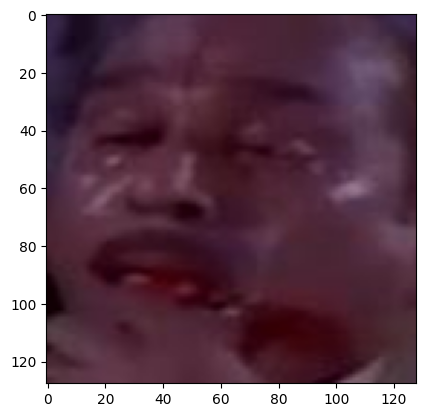

In [15]:
import random
idx = 119
img_name = test.ID[idx]

img = imageio.v2.imread(os.path.join('Test/Test', img_name))
plt.imshow(np.array(Image.fromarray(img).resize((128, 128))))


In [16]:
pred_probabilities = model.predict(test_x)
pred_classes = np.argmax(pred_probabilities, axis=1) 

print('Original:', train.Class[idx], 'Predicted:', 
      lb.inverse_transform([pred_classes[idx]])[0])

208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Original: MIDDLE Predicted: MIDDLE
